Aadesh Shrestha




3 Image Compression and Decompression using PCA.<br>
2.1 Exercise- 1:



In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

1. Read and display the image.


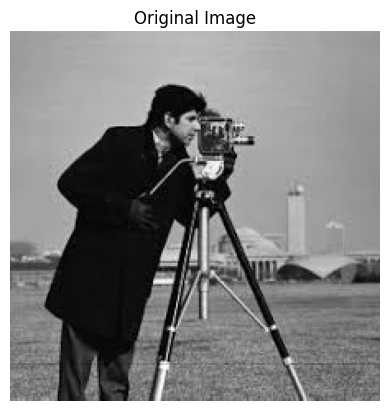

In [2]:
# Load image
img = Image.open("cameraman.jpeg")

# Convert to numpy array
img_array = np.array(img)

# Display image
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

2. Display only the top left corner of 100x100 pixels.


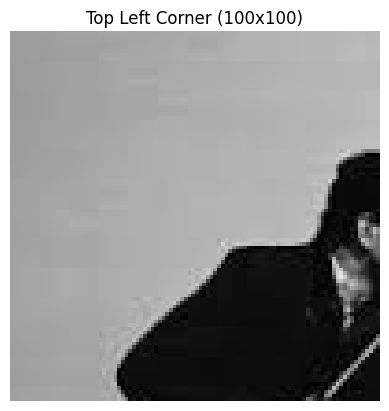

In [3]:
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left Corner (100x100)")
plt.axis("off")
plt.show()

3. Show the three color channels (R, G, B).


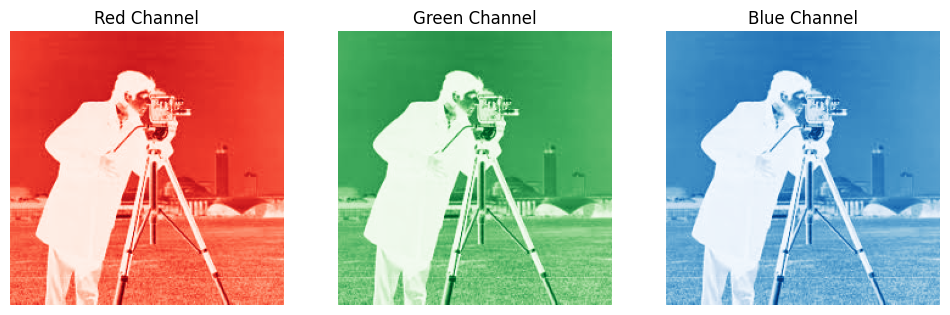

In [4]:
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

4. Modify the top 100 ×100 pixels to a value of 210 and display the resulting image:


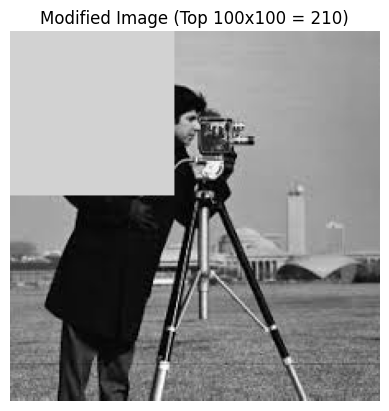

In [5]:
modified = img_array.copy()

modified[0:100,0:100] = 210

plt.imshow(modified)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

2.2 Exercise- 2:

1. Load and display a grayscale image.


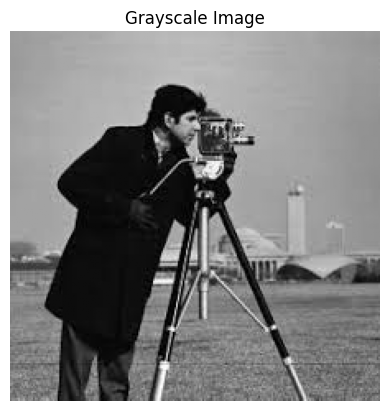

In [7]:
gray = Image.open("cameraman.jpeg").convert("L")

gray_array = np.array(gray)

plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

2. Extract and display the middle section of the image (150 pixels).


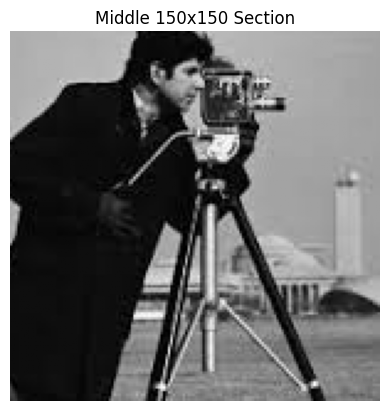

In [8]:
h, w = gray_array.shape

center_crop = gray_array[
    h//2 - 75 : h//2 + 75,
    w//2 - 75 : w//2 + 75
]

plt.imshow(center_crop, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).


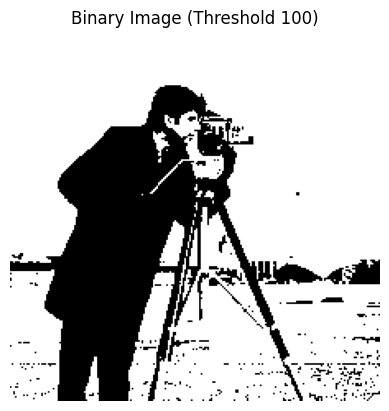

In [9]:
binary = np.where(gray_array < 100, 0, 255)

plt.imshow(binary, cmap="gray")
plt.title("Binary Image (Threshold 100)")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.


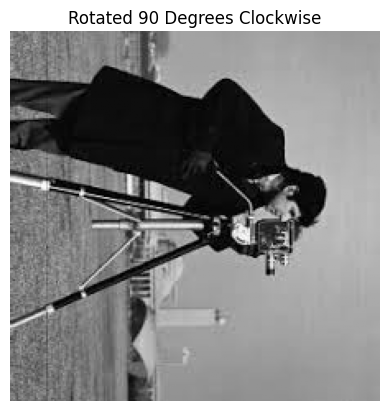

In [10]:
rotated = np.rot90(gray_array, -1)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.


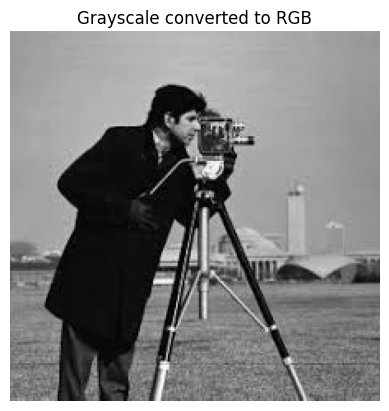

In [11]:
rgb = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb)
plt.title("Grayscale converted to RGB")
plt.axis("off")
plt.show()

3 Image Compression and Decompression using PCA.


1. Load and Prepare Data:


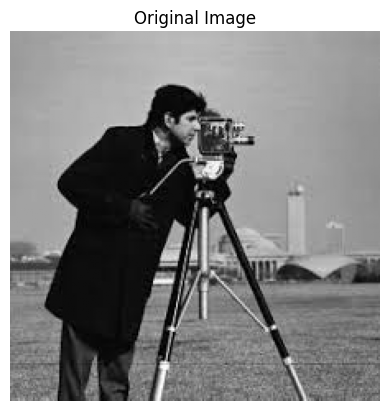

In [15]:
img = Image.open("cameraman.jpeg").convert("L")
img = np.array(img)

plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

mean = np.mean(img, axis=0)

X = img - mean

cov = np.cov(X, rowvar=False)

2. Eigen Decomposition and Identifying Principal Components:


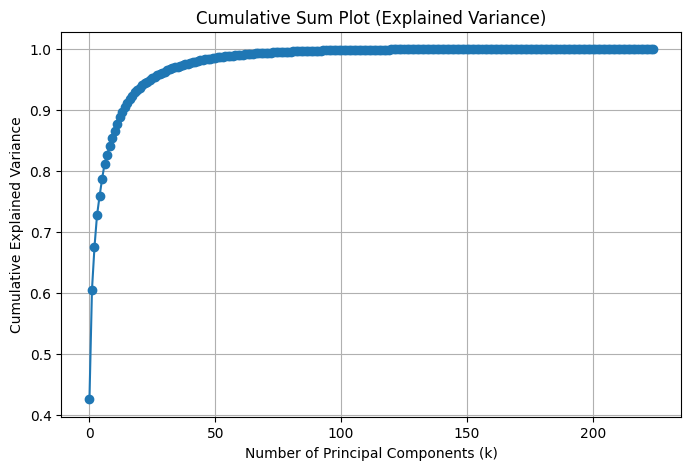

In [19]:
eigenvalues, eigenvectors = np.linalg.eigh(cov)

idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:,idx]

k = 50

PC = eigenvectors[:,:k]

explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Sum Plot (Explained Variance)")
plt.grid(True)
plt.show()


3. Reconstruction and Experiment:


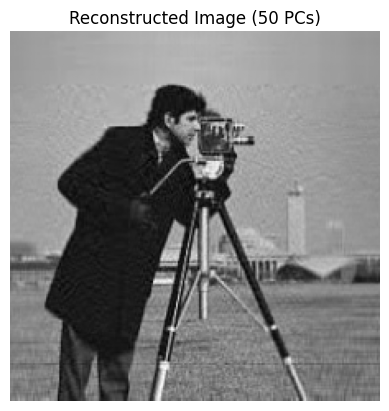

In [17]:
compressed = np.dot(X, PC)

reconstructed = np.dot(compressed, PC.T) + mean

plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed Image (50 PCs)")
plt.axis("off")
plt.show()

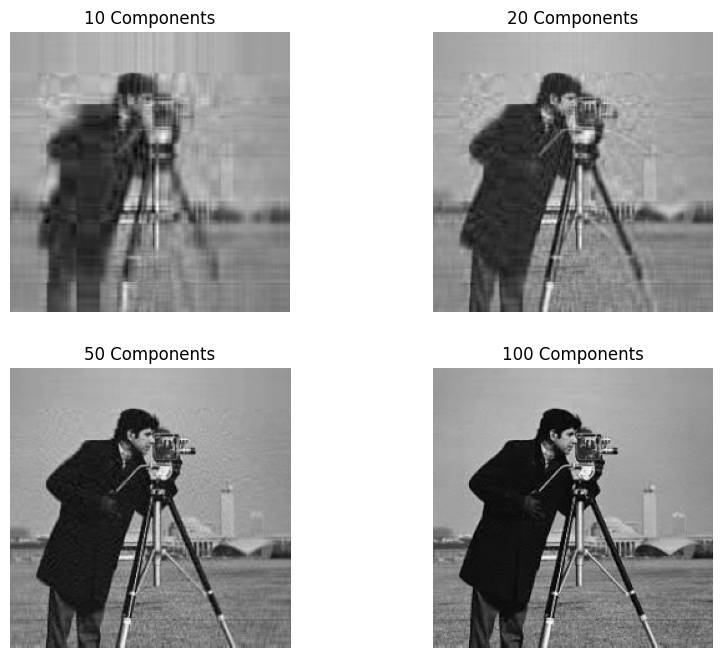

In [18]:
components = [10, 20, 50, 100]

plt.figure(figsize=(10,8))

for i,k in enumerate(components):

    PC = eigenvectors[:,:k]
    compressed = np.dot(X, PC)
    recon = np.dot(compressed, PC.T) + mean

    plt.subplot(2,2,i+1)
    plt.imshow(recon, cmap="gray")
    plt.title(f"{k} Components")
    plt.axis("off")

plt.show()